In [19]:
import pandas as pd
import numpy as np

# ------------------------
# Load
# ------------------------

df = pd.read_json("data/dataset_14_04_26_EN_newicd_ccs.json")

disease_mapper = dict(zip(
    list(df["base_pathology_area"].unique()),
    ["SCD", "CHA", "NHOC", "AS", "AHD", "NTDT", "IM", "TDT", "OD"]
))

df.replace(disease_mapper, inplace=True)
df.replace({"is_alive?": {"n/a": "YES"}}, inplace=True)

df["dead"] = df["is_alive?"].eq("NO")
df["splen"] = df["is_splenectomized?"].eq("YES")

summary = (
    df.groupby("base_pathology_area")
    .agg(
        Total=("base_pathology_area", "size"),
        Splen=("splen", "sum"),
        SplenDeath=("dead", lambda x: ((x) & df.loc[x.index, "splen"]).sum()),
        Male=("gender", lambda x: x.eq("M").sum()),
        Female=("gender", lambda x: x.eq("F").sum()),
        MaleDeath=("dead", lambda x: ((x) & df.loc[x.index, "gender"].eq("M")).sum()),
        FemaleDeath=("dead", lambda x: ((x) & df.loc[x.index, "gender"].eq("F")).sum()),
        TotalDeaths=("dead", "sum")
    )
    .reset_index()
    .rename(columns={"base_pathology_area": "Disease"})
)

summary["NoSplen"] = summary["Total"] - summary["Splen"]
summary["NoSplenDeath"] = summary["TotalDeaths"] - summary["SplenDeath"]

summary["SplenRate"] = summary["Splen"] / summary["Total"] * 100
summary["NoSplenRate"] = summary["NoSplen"] / summary["Total"] * 100

summary["Mortality"] = summary["TotalDeaths"] / summary["Total"] * 100

summary["MortSplen"] = (
    summary["SplenDeath"] /
    summary["Splen"].replace(0, np.nan) * 100
)

summary["MortNoSplen"] = (
    summary["NoSplenDeath"] /
    summary["NoSplen"].replace(0, np.nan) * 100
)

summary["MortMale"] = (
    summary["MaleDeath"] /
    summary["Male"].replace(0, np.nan) * 100
)

summary["MortFemale"] = (
    summary["FemaleDeath"] /
    summary["Female"].replace(0, np.nan) * 100
)

summary = summary.sort_values("Total", ascending=False)

summary

,Disease,Total,Splen,SplenDeath,Male,Female,MaleDeath,FemaleDeath,TotalDeaths,NoSplen,NoSplenDeath,SplenRate,NoSplenRate,Mortality,MortSplen,MortNoSplen,MortMale,MortFemale
2,CHA,506,506,3,269,237,1,2,3,0,0,100.000000,0.000000,0.592885,0.592885,NaN,0.371747,0.843882
7,SCD,402,118,5,199,203,8,8,16,284,11,29.353234,70.646766,3.980100,4.237288,3.873239,4.020101,3.940887
8,TDT,383,383,78,200,183,44,34,78,0,0,100.000000,0.000000,20.365535,20.365535,NaN,22.000000,18.579235
5,NTDT,181,181,37,96,85,24,13,37,0,0,100.000000,0.000000,20.441989,20.441989,NaN,25.000000,15.294118
0,AHD,144,143,4,71,73,3,1,4,1,0,99.305556,0.694444,2.777778,2.797203,0.000000,4.225352,1.369863
4,NHOC,90,90,2,54,36,1,1,2,0,0,100.000000,0.000000,2.222222,2.222222,NaN,1.851852,2.777778
6,OD,60,60,7,36,24,5,2,7,0,0,100.000000,0.000000,11.666667,11.666667,NaN,13.888889,8.333333
1,AS,13,1,1,3,10,1,3,4,12,3,7.692308,92.307692,30.769231,100.000000,25.000000,33.333333,30.000000
3,IM,10,10,2,8,2,0,2,2,0,0,100.000000,0.000000,20.000000,20.000000,NaN,0.000000,100.000000


<Figure size 640x480 with 0 Axes>

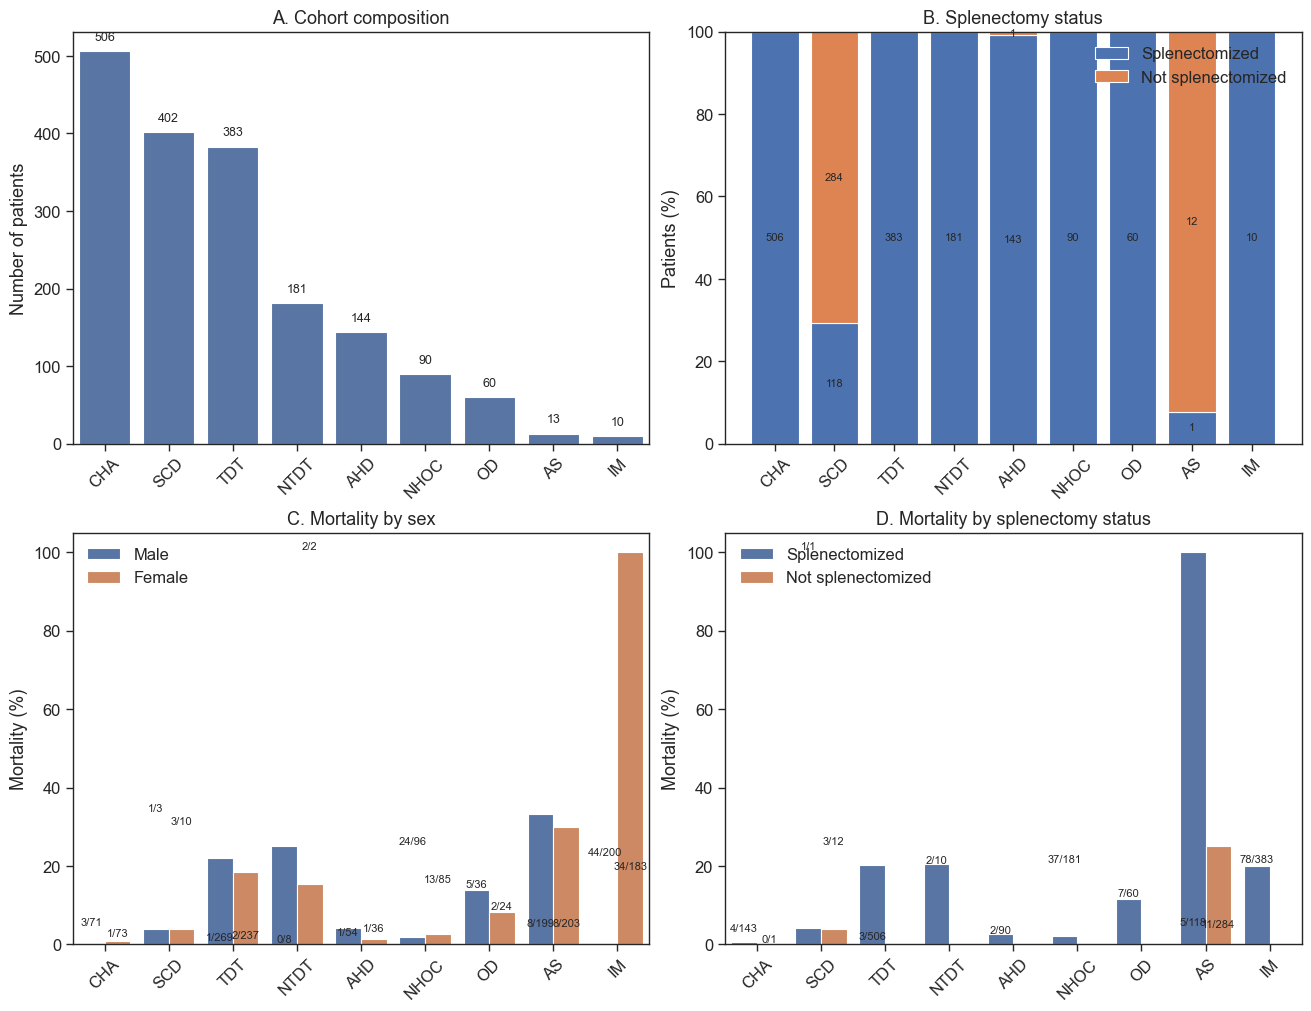

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = summary.copy()

palette = {
    "Male": "#4C72B0",
    "Female": "#DD8452",
    "Splenectomized": "#55A868",
    "Not splenectomized": "#C44E52"
}
sns.set_theme(
    style="ticks",
    context="paper",
    font_scale=1.35
)

sns.despine()

fig, axs = plt.subplots(
    2,2,
    figsize=(13,10),
    constrained_layout=True
)

# -------------------------
# PANEL A
# Cohort composition
# -------------------------

tmp = df.sort_values("Total", ascending=False)

sns.barplot(
    data=tmp,
    x="Disease",
    y="Total",
    ax=axs[0,0],
    palette=palette
)

for i, row in enumerate(tmp.itertuples()):
    axs[0,0].text(
        i,
        row.Total + max(df["Total"]) * 0.02,
        f"{row.Total}",
        ha="center",
        va="bottom",
        fontsize=9
    )

axs[0,0].set_title("A. Cohort composition")
axs[0,0].set_xlabel("")
axs[0,0].set_ylabel("Number of patients")
axs[0,0].tick_params(axis="x", rotation=45)


# -------------------------
# PANEL B
# Splenectomy status
# -------------------------

tmp = df.sort_values("Total", ascending=False)

axs[0,1].bar(
    tmp["Disease"],
    tmp["SplenRate"],
    label="Splenectomized"
)

axs[0,1].bar(
    tmp["Disease"],
    100 - tmp["SplenRate"],
    bottom=tmp["SplenRate"],
    label="Not splenectomized"
)

for i, row in enumerate(tmp.itertuples()):
    axs[0,1].text(
        i,
        row.SplenRate / 2,
        f"{int(row.Splen)}",
        ha="center",
        va="center",
        fontsize=8
    )
    
    if row.NoSplen > 0:
        axs[0,1].text(
            i,
            row.SplenRate + (100 - row.SplenRate) / 2,
            f"{int(row.NoSplen)}",
            ha="center",
            va="center",
            fontsize=8
        )

axs[0,1].set_ylim(0,100)
axs[0,1].set_title("B. Splenectomy status")
axs[0,1].set_xlabel("")
axs[0,1].set_ylabel("Patients (%)")
axs[0,1].legend(frameon=False)
axs[0,1].tick_params(axis="x", rotation=45)


# -------------------------
# PANEL C
# Mortality by sex
# -------------------------

sex_long = pd.melt(
    summary,
    id_vars=["Disease", "Male", "Female", "MaleDeath", "FemaleDeath"],
    value_vars=["MortMale", "MortFemale"],
    var_name="Group",
    value_name="MortalityRate"
)

sex_long["Group"] = sex_long["Group"].replace({
    "MortMale": "Male",
    "MortFemale": "Female"
})

sns.barplot(
    data=sex_long,
    x="Disease",
    y="MortalityRate",
    hue="Group",
    ax=axs[1,0],
    palette=palette
)

# labels

bar_width = 0.4

for i, row in summary.iterrows():

    # Male
    if row["Male"] > 0:
        axs[1,0].text(
            i - bar_width/2,
            row["MortMale"] + 0.6,
            f"{int(row['MaleDeath'])}/{int(row['Male'])}",
            ha="center",
            fontsize=8
        )

    # Female
    if row["Female"] > 0:
        axs[1,0].text(
            i + bar_width/2,
            row["MortFemale"] + 0.6,
            f"{int(row['FemaleDeath'])}/{int(row['Female'])}",
            ha="center",
            fontsize=8
        )

axs[1,0].set_title("C. Mortality by sex")
axs[1,0].set_xlabel("")
axs[1,0].set_ylabel("Mortality (%)")
axs[1,0].tick_params(axis="x", rotation=45)
axs[1,0].legend(title="", frameon=False)

# -------------------------
# PANEL D
# Mortality by splenectomy
# -------------------------

long = pd.melt(
    summary,
    id_vars=[
        "Disease",
        "Splen",
        "NoSplen",
        "SplenDeath",
        "NoSplenDeath"
    ],
    value_vars=[
        "MortSplen",
        "MortNoSplen"
    ],
    var_name="Group",
    value_name="MortalityRate"
)

long["Group"] = long["Group"].replace({
    "MortSplen": "Splenectomized",
    "MortNoSplen": "Not splenectomized"
})

sns.barplot(
    data=long,
    x="Disease",
    y="MortalityRate",
    hue="Group",
    ax=axs[1,1],
    palette=palette
)

for i, row in summary.iterrows():

    if row["Splen"] > 0:

        axs[1,1].text(
            i - bar_width/2,
            row["MortSplen"] + 0.6,
            f"{int(row['SplenDeath'])}/{int(row['Splen'])}",
            ha="center",
            fontsize=8
        )

    if row["NoSplen"] > 0:

        axs[1,1].text(
            i + bar_width/2,
            row["MortNoSplen"] + 0.6,
            f"{int(row['NoSplenDeath'])}/{int(row['NoSplen'])}",
            ha="center",
            fontsize=8
        )

axs[1,1].set_title("D. Mortality by splenectomy status")
axs[1,1].set_xlabel("")
axs[1,1].set_ylabel("Mortality (%)")
axs[1,1].tick_params(axis="x", rotation=45)
axs[1,1].legend(title="", frameon=False)